# IOT project , Data analysis - Axel Biegalski

## Setup & Import

In [1]:
import pandas as pd 
import numpy as np
import math
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import pymongo
from pymongo import MongoClient
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder


#https://www.geeksforgeeks.org/mongodb/connecting-mongodb-to-jupyter-notebook/

## Db Connexion (MongoDB)

### Bind DB

In [2]:
client = MongoClient("localhost", 27017)
db = client['iot_db']
training_set = db['training_set']

### Count instances

In [3]:
L = ['Room', 'Bathroom', 'NUC']
for element in L:
    count = training_set.count_documents({ "payload.location": element })
    print(f"Number of documents with location = {element} : {count}")

Number of documents with location = Room : 202
Number of documents with location = Bathroom : 206
Number of documents with location = NUC : 226


## Create Dataset object (Pandas Dataframe)

In [4]:
data = []
# parse db
for doc in training_set.find():
    payload = doc.get('payload', {})
    temp = payload.get('temp')
    humidity = payload.get('humidity')
    location = payload.get('location')
    time = payload.get('time')
    
    
    if temp is not None and humidity is not None and location is not None and time is not None:
        data.append({
            'time': time,
            'temperature': temp,
            'humidity': humidity,
            'location': location  
        })

# Create dataframe using pandas
df = pd.DataFrame(data)
display(df)

,time,temperature,humidity,location
0,1.762090e+12,21.0,37,Room
1,1.762090e+12,20.9,38,Room
2,1.762090e+12,21.0,37,Room
3,1.762090e+12,21.0,37,Room
4,1.762090e+12,21.0,37,Room
...,...,...,...,...
629,1.762092e+12,30.8,15,NUC
630,1.762092e+12,30.2,15,NUC
631,1.762092e+12,30.2,15,NUC
632,1.762092e+12,29.9,16,NUC


## Dataset Analysis 

### Infos 

In [5]:
##info
df.describe()
print(f"Missing Atts:\n{df.isna().sum()}") ## no missing attributes

Missing Atts:
time           0
temperature    0
humidity       0
location       0
dtype: int64


### Pearson Correlation Matrix

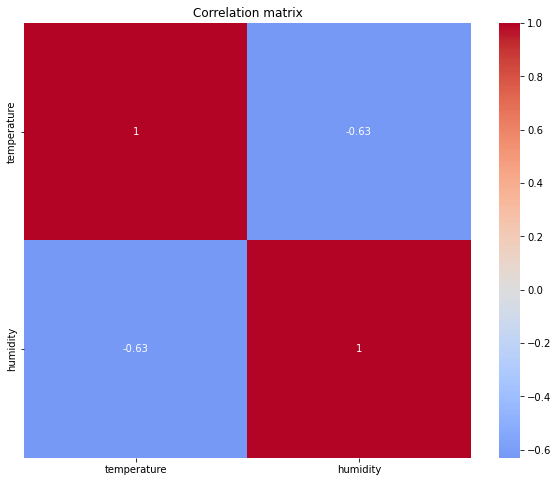

In [6]:
##Create copy of dataset and drop class instance (categorial data)
df2 = df.copy()
df2 = df2.drop(columns=['location','time'])
## Compute correlation (Pearson) matrix
corr_matrix = df2.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation matrix")
plt.show()

### Data Visualization 

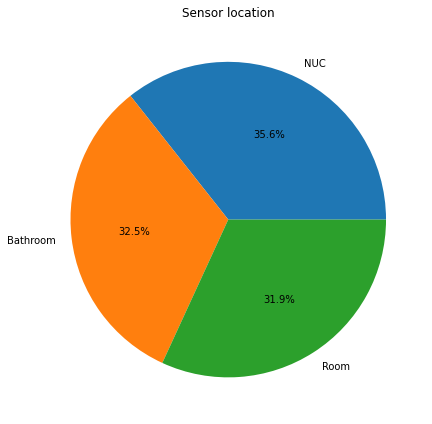

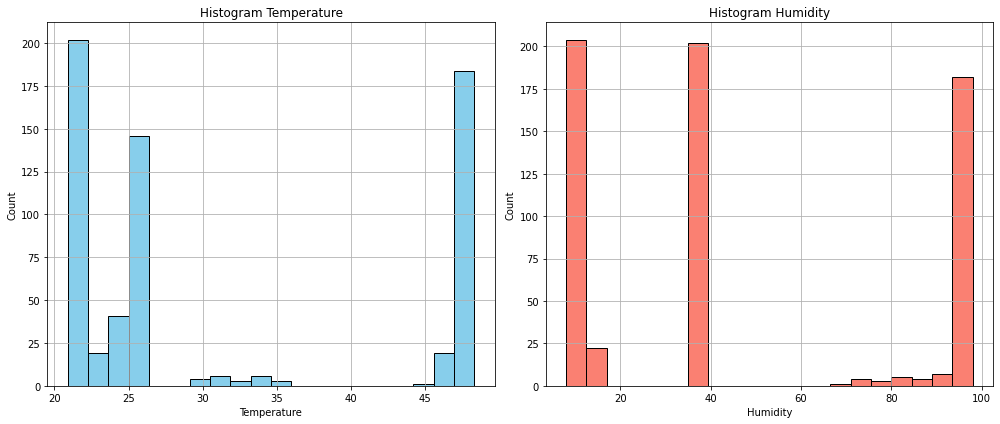

In [7]:
# Visualization : Pie chart of location
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
df['location'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=sns.color_palette(), ax=ax
)
ax.set_title('Sensor location')
ax.set_ylabel('')
plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 ligne, 2 colonnes

df['temperature'].hist(ax=axes[0], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram Temperature')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Count')

df['humidity'].hist(ax=axes[1], bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Histogram Humidity')
axes[1].set_xlabel('Humidity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Clustering using K-means algorithm

In [8]:
## functions
## plot clusters 
def plot_clusters(X, ax, color='blue', alpha=0.7, label=None):
    return ax.scatter(X[:, 0], X[:, 1], c=color, s=20, alpha=alpha, label=label)

##plot data with decision boundaries
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 10
    maxs = X.max(axis=0) + 10
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

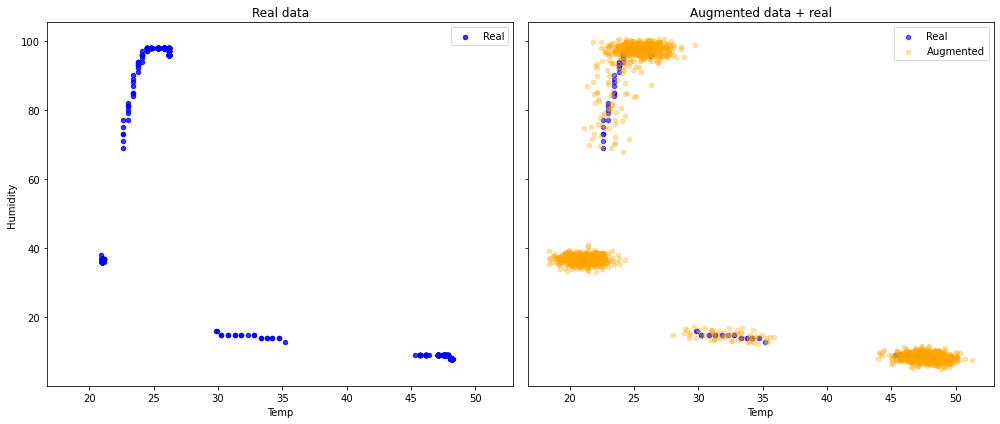

In [9]:
# noise parameter
noise_level_temp = 1
noise_level_hum = 1.0
N_aug = 3

# Real
X_real = df[['temperature', 'humidity']].to_numpy()

#augment dataset
X_aug_list = []
for x in X_real:
    noise_temp = np.random.normal(0, noise_level_temp, N_aug)
    noise_hum = np.random.normal(0, noise_level_hum, N_aug)
    augmented_points = np.column_stack((x[0] + noise_temp, x[1] + noise_hum))
    X_aug_list.append(augmented_points)
X_aug = np.vstack(X_aug_list)

#plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
# left: real
plot_clusters(X_real, axes[0], color='blue', alpha=0.8, label='Real')
axes[0].set_title("Real data")
axes[0].set_xlabel("Temp")
axes[0].set_ylabel("Humidity")
axes[0].legend()
# right: augmented dataset
plot_clusters(X_real, axes[1], color='blue', alpha=0.6, label='Real')
plot_clusters(X_aug, axes[1], color='orange', alpha=0.3, label='Augmented')
axes[1].set_title("Augmented data + real")
axes[1].set_xlabel("Temp")
axes[1].legend()

##show
plt.tight_layout()
plt.show()

In [10]:
## => 4 clusters instead of 3 , lets clear garbage data
df_filtered = df[
    (df['humidity'] >= 0) & (df['humidity'] <= 20) &
    (df['temperature'] >= 25) & (df['temperature'] <= 40)
]
print(df_filtered.value_counts())
df3 = df.copy()
df3 = df3[
    ~(
        (df['humidity'] >= 0) & (df['humidity'] <= 20) &
        (df['temperature'] >= 25) & (df['temperature'] <= 40)
    )
]


## then re assign X_real
X_real = df3[['temperature', 'humidity']].to_numpy()

time          temperature  humidity  location
1.762092e+12  35.2         13        NUC         1
              34.7         14        NUC         1
                                     NUC         1
              34.2         14        NUC         1
                                     NUC         1
              33.8         14        NUC         1
                                     NUC         1
              33.3         14        NUC         1
                                     NUC         1
              32.8         15        NUC         1
                                     NUC         1
              32.3         15        NUC         1
              31.8         15        NUC         1
                                     NUC         1
              31.3         15        NUC         1
                                     NUC         1
              30.8         15        NUC         1
                                     NUC         1
              30.2         15       

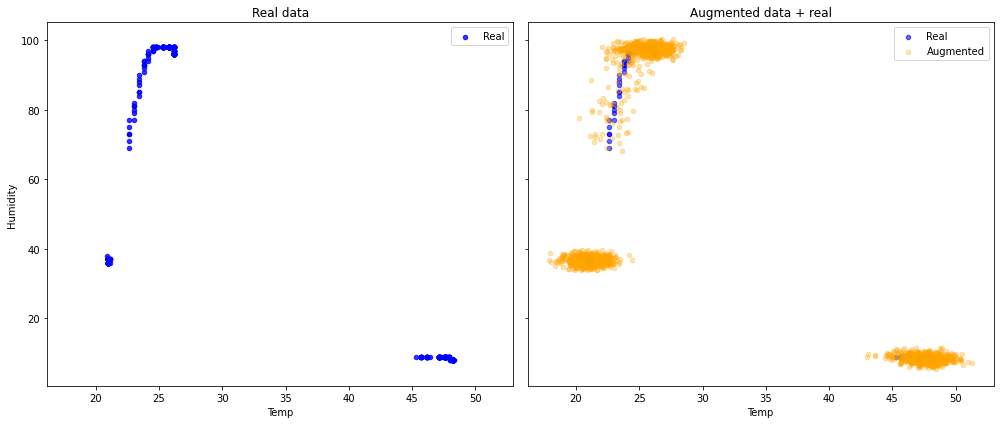

In [11]:
## plot again
#augment dataset
X_aug_list = []
for x in X_real:
    noise_temp = np.random.normal(0, noise_level_temp, N_aug)
    noise_hum = np.random.normal(0, noise_level_hum, N_aug)
    augmented_points = np.column_stack((x[0] + noise_temp, x[1] + noise_hum))
    X_aug_list.append(augmented_points)
X_aug = np.vstack(X_aug_list)

#plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
# left: real
plot_clusters(X_real, axes[0], color='blue', alpha=0.8, label='Real')
axes[0].set_title("Real data")
axes[0].set_xlabel("Temp")
axes[0].set_ylabel("Humidity")
axes[0].legend()
# right: augmented dataset
plot_clusters(X_real, axes[1], color='blue', alpha=0.6, label='Real')
plot_clusters(X_aug, axes[1], color='orange', alpha=0.3, label='Augmented')
axes[1].set_title("Augmented data + real")
axes[1].set_xlabel("Temp")
axes[1].legend()

##show
plt.tight_layout()
plt.show()

In [12]:
## k means alg
k = 3
kmeans = KMeans(n_clusters=k, n_init=100,random_state=47)
y_pred = kmeans.fit_predict(X_real)
y_pred is kmeans.labels_
kmeans.cluster_centers_

array([[21.00247525, 36.79207921],
       [25.32135922, 95.76699029],
       [47.72352941,  8.45588235]])

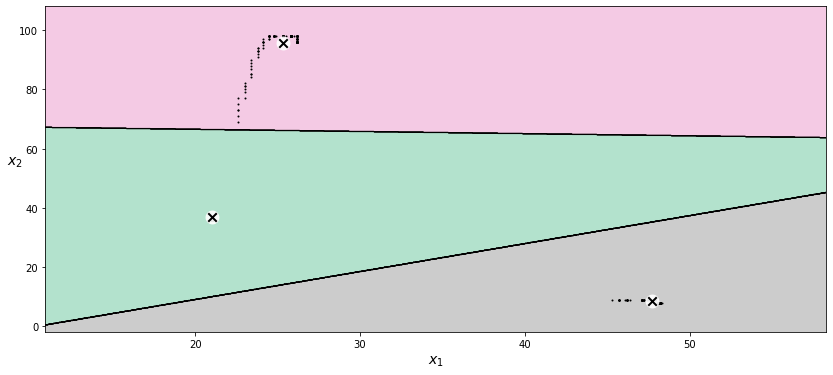

In [13]:
plt.figure(figsize=(14, 6))
plot_decision_boundaries(kmeans, X_real)
plt.show()

### Elbow Criteria

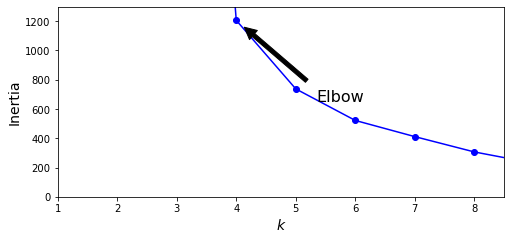

In [14]:
## find the best inertia using Elbow criteria 
kmeans_per_k = [KMeans(n_clusters=k, n_init=10,random_state=42).fit(X_real)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.annotate('Elbow',
             xy=(4, inertias[3]),
             xytext=(0.55, 0.55),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )
plt.axis([1, 8.5, 0, 1300])
plt.show()

### Silhouet Method

For n_clusters = 2 The average silhouette_score is : 0.7954691609365774
For n_clusters = 3 The average silhouette_score is : 0.9620093446842011
For n_clusters = 4 The average silhouette_score is : 0.9487021623205333
For n_clusters = 5 The average silhouette_score is : 0.9239093910093524
For n_clusters = 6 The average silhouette_score is : 0.9073749068865781


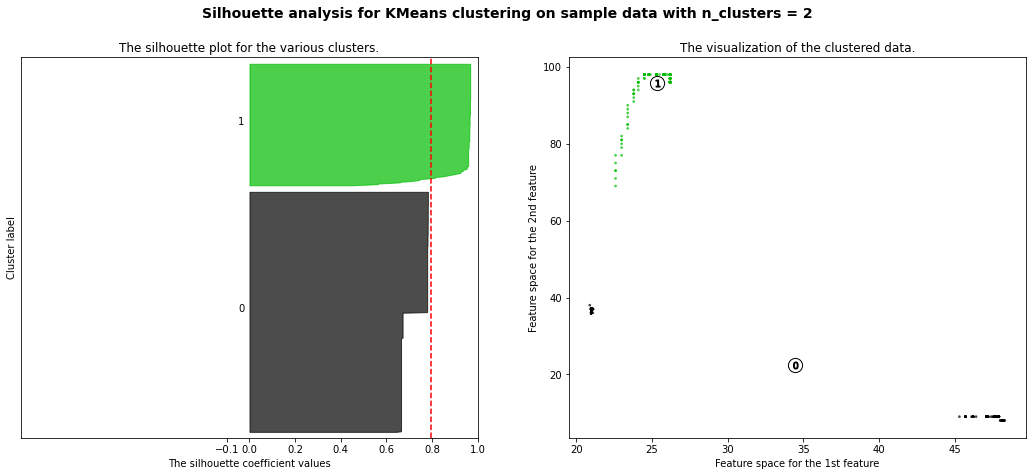

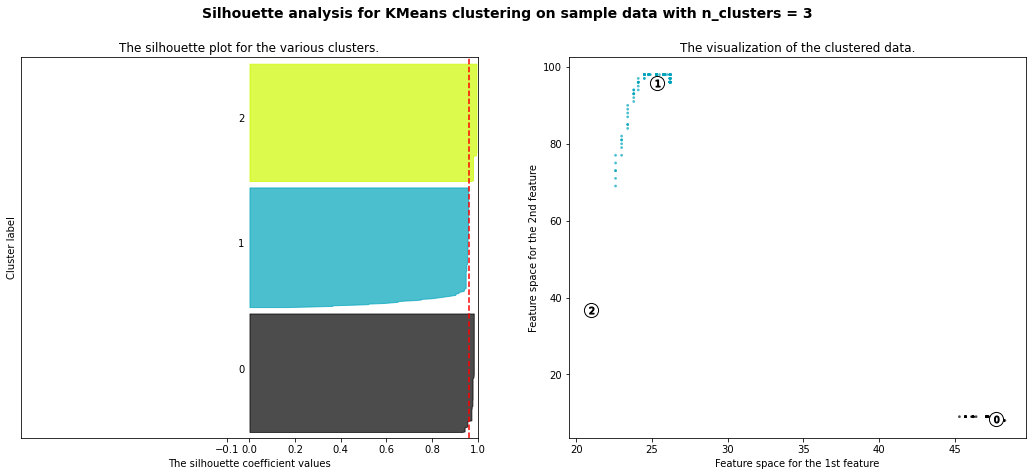

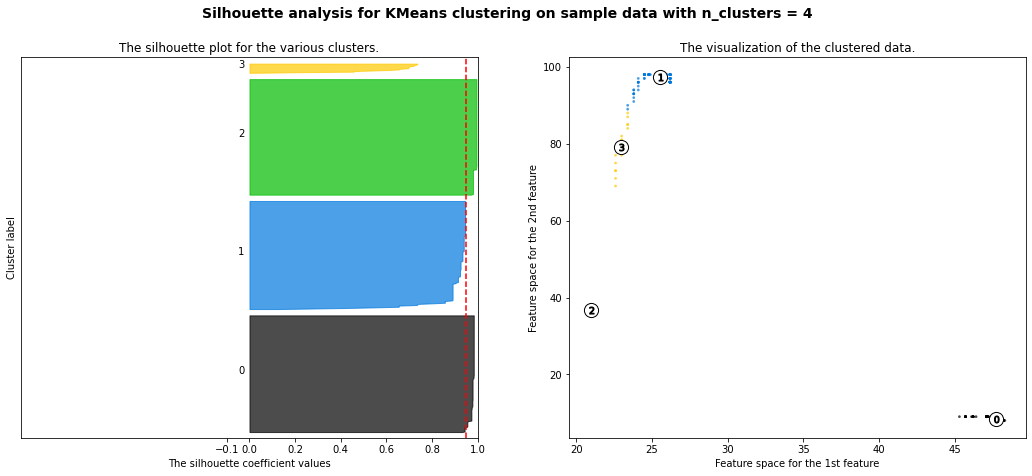

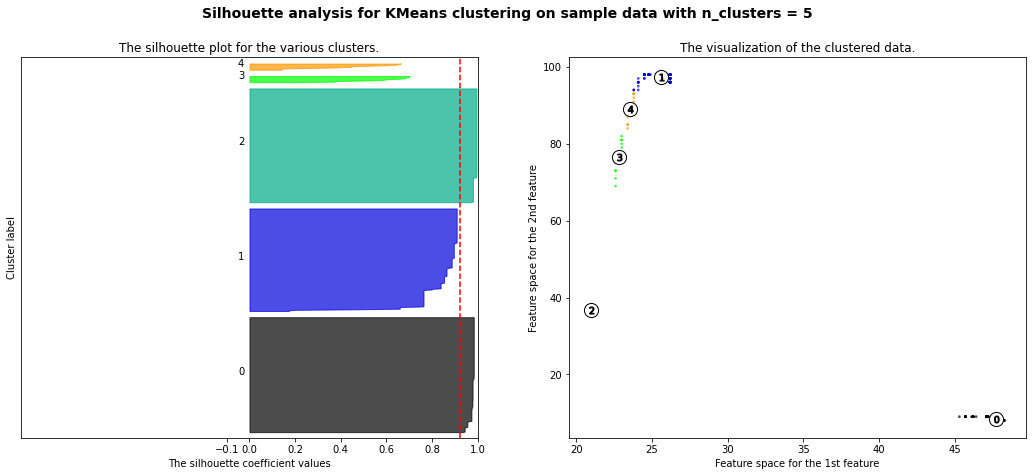

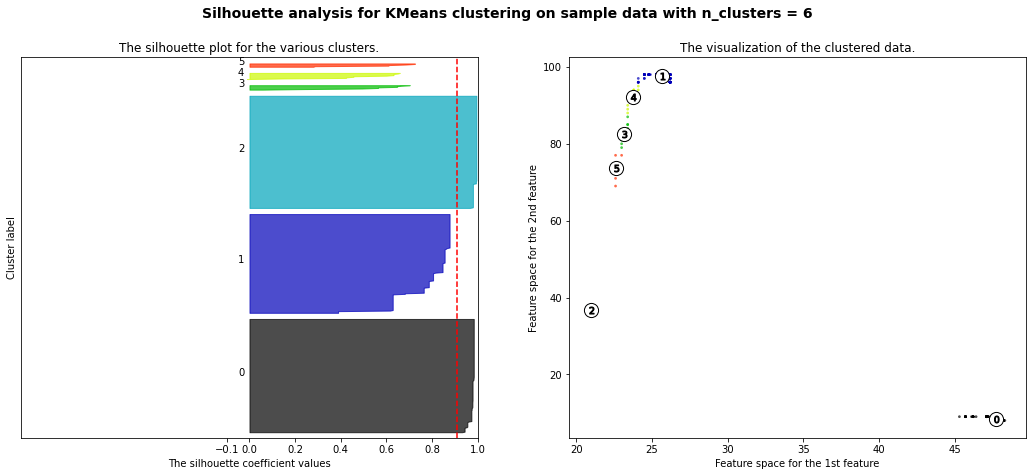

In [15]:
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X_real) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=10)
    cluster_labels = clusterer.fit_predict(X_real)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X_real, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X_real, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X_real[:, 0], X_real[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

### Test trained model with real data

In [16]:
# Class : room
test_set = db['iot_testset']
L = ['room', 'NUC']
for element in L:
    count = test_set.count_documents({ "payload.location": element })
    print(f"Nombre de documents avec payload.location = {element} : {count}")

Nombre de documents avec payload.location = room : 32
Nombre de documents avec payload.location = NUC : 48


In [17]:
## create dataframe
data = []
# parse db
for doc in test_set.find():
    payload = doc.get('payload', {})
    temp = payload.get('temp')
    humidity = payload.get('humidity')
    location = payload.get('location')
    time = payload.get('time')
    
    
    if temp is not None and humidity is not None and location is not None and time is not None:
        data.append({
            'time': time,
            'temperature': temp,
            'humidity': humidity,
            'location': location  
        })

# Create dataframe using pandas
df = pd.DataFrame(data)
display(df)

,time,temperature,humidity,location
0,1.762700e+12,22.2,45,room
1,1.762700e+12,22.2,45,room
2,1.762700e+12,22.2,45,room
3,1.762700e+12,22.2,45,room
4,1.762700e+12,22.2,45,room
...,...,...,...,...
75,1.762703e+12,39.5,19,NUC
76,1.762703e+12,39.5,19,NUC
77,1.762703e+12,39.5,18,NUC
78,1.762703e+12,39.5,18,NUC


In [18]:
## test set X & Y
X = df[['temperature', 'humidity']].to_numpy()
Y = df['location'].to_numpy()
## kmeans.cluster_centers_ ==> kmeans centers after training

In [19]:
Y_pred = kmeans.predict(X)
print(Y_pred)
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)  

confusion_matrix(Y_encoded,Y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2]


array([[ 0,  0, 48],
       [32,  0,  0],
       [ 0,  0,  0]])

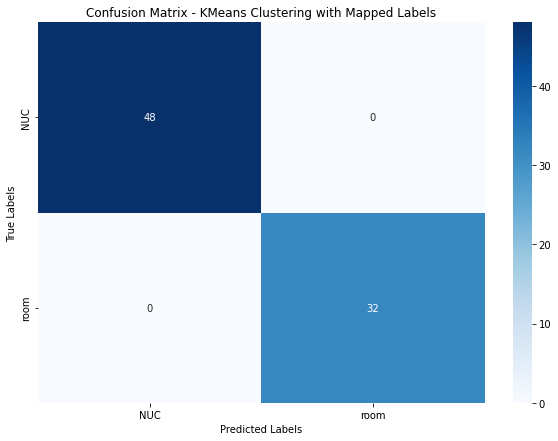

In [20]:
df_results = pd.DataFrame({'label': Y, 'cluster': Y_pred})

# mapp labels
mapping = df_results.groupby('cluster')['label'].agg(lambda x: x.value_counts().idxmax())
Y_pred_mapped = [mapping[c] for c in Y_pred]

# conf matric
labels = sorted(list(set(Y)))  # sort by class
cm = confusion_matrix(Y, Y_pred_mapped, labels=labels)

# print matrix
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - KMeans Clustering with Mapped Labels')
plt.show()